### Classification in Business

<center>
    <img src = 'images/uci_biz.png' />
</center>



------------


For this try-it, you are to explore some available datasets related to business applications of classification.  Using a dataset from the UCI Machine Learning Repository, scan datasets   under the subject area "BUSINESS" [link here](https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business).  Find a dataset that looks interesting to you and decide how you could use Logistic Regression to help make a business decision using the data. 

In sharing your results, be sure to clearly describe the following:

- the dataset and its features
- the classification problem -- what are you classifying here?
- a business decision that can be supported using the results of the classification model

Share your summary on the appropriate discussion board for the activity. 

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import seaborn as sns

In [4]:
customers = pd.read_csv('./Wholesale customers data.csv')

In [5]:
customers.head(5)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [7]:
customers.Channel.unique()

array([2, 1])

In [9]:
customers.groupby('Channel').count()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,,
1,298,298,298,298,298,298,298
2,142,142,142,142,142,142,142


In [13]:
customers.groupby('Channel')['Fresh'].sum()


Channel
1    4015717
2    1264414
Name: Fresh, dtype: int64

In [14]:
customers['Channel_Name'] = customers['Channel'].map({
    1: 'HORECA',
    2: 'Retail'
})

customers.groupby('Channel_Name')['Fresh'].sum()


Channel_Name
HORECA    4015717
Retail    1264414
Name: Fresh, dtype: int64

In [15]:
X = customers[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']]
y = customers['Channel']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [18]:
pipe.score(X_test, y_test)


0.9090909090909091

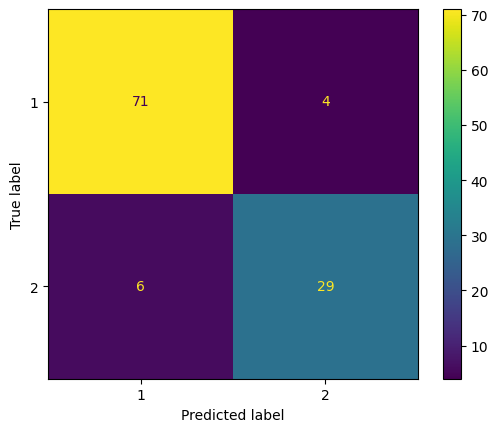

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    pipe, X_test, y_test
)


In [20]:
pd.Series(
    pipe.named_steps['logreg'].coef_[0],
    index=X.columns
).sort_values()


Frozen             -0.659449
Delicassen         -0.310916
Fresh               0.082744
Milk                0.865981
Grocery             1.170844
Detergents_Paper    3.049884
dtype: float64

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipe.fit(X_train, y_train)
knn_pipe.score(X_test, y_test)


0.9363636363636364

In [22]:
from sklearn.metrics import classification_report

y_pred = knn_pipe.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.95      0.96      0.95        75
           2       0.91      0.89      0.90        35

    accuracy                           0.94       110
   macro avg       0.93      0.92      0.93       110
weighted avg       0.94      0.94      0.94       110



In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Pipeline
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Parameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Grid search
grid = GridSearchCV(
    knn_pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [24]:
grid.best_params_


{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}

In [25]:
best_knn = grid.best_estimator_

best_knn.score(X_test, y_test)


0.9272727272727272

In [26]:
from sklearn.metrics import classification_report

y_pred = best_knn.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.95      0.95      0.95        75
           2       0.89      0.89      0.89        35

    accuracy                           0.93       110
   macro avg       0.92      0.92      0.92       110
weighted avg       0.93      0.93      0.93       110



In [27]:
from sklearn.linear_model import LogisticRegression

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    logreg_pipe,
    param_grid_lr,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train, y_train)

grid_lr.best_estimator_.score(X_test, y_test)


0.9090909090909091

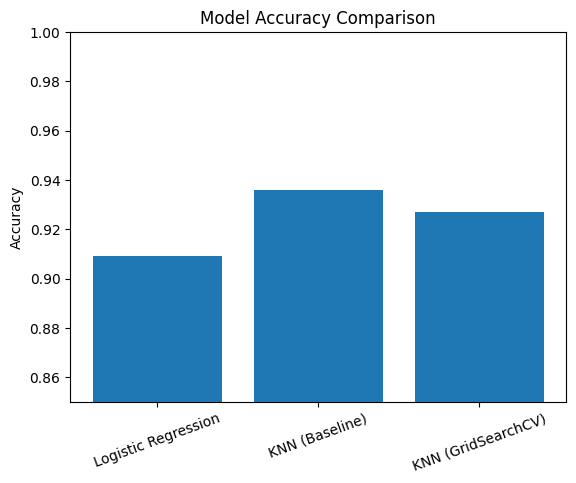

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN (Baseline)',
        'KNN (GridSearchCV)'
    ],
    'Accuracy': [
        0.909,
        0.936,
        0.927
    ]
})

plt.figure()
plt.bar(results['Model'], results['Accuracy'])
plt.ylim(0.85, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.savefig('Model_Accuracy_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()


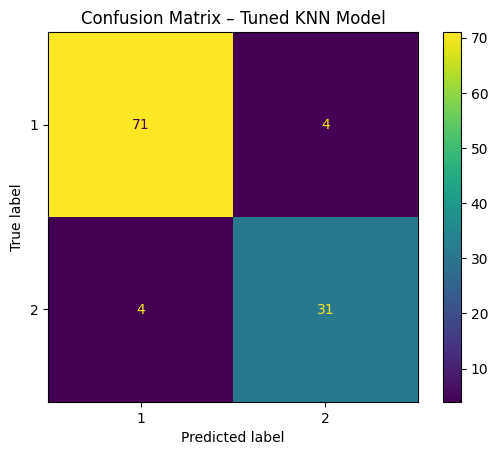

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_knn,
    X_test,
    y_test
)
plt.title('Confusion Matrix – Tuned KNN Model')
plt.savefig('confusion_matrix_knn.png', dpi=300, bbox_inches='tight')
plt.show()


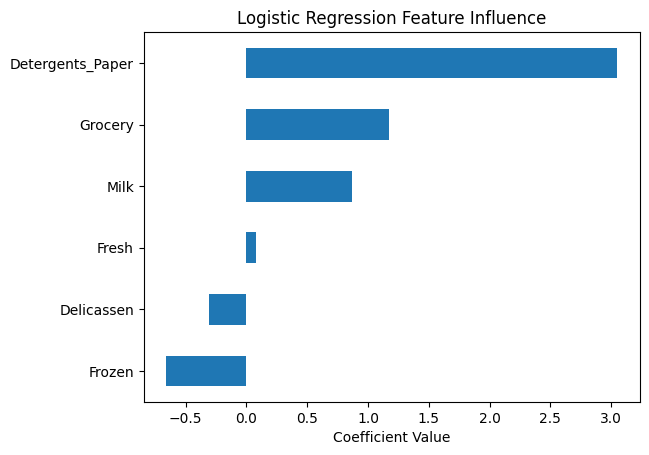

In [33]:
import pandas as pd

coef = pd.Series(
    pipe.named_steps['logreg'].coef_[0],
    index=X.columns
).sort_values()

plt.figure()
coef.plot(kind='barh')
plt.title('Logistic Regression Feature Influence')
plt.xlabel('Coefficient Value')
plt.savefig('logreg_feature_influence.png', dpi=300, bbox_inches='tight')
plt.show()
